# Model Panel Sensitivity Analysis
This notebook analyzes model-level annotation behavior reported in 
Appendix of the paper:
> **Beyond Black-Box Labels: Interpretable Criteria for Diagnosing Subjective NLP Tasks**


## 1. Setup

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────
TENSOR_NPY  = Path("../data/tensors/run_2026-04-13_14-00_FULL_AGGREGATED/tensor_raw_4700.npy")
MAPPING_CSV = Path("../data/tensors/run_2026-04-13_14-00_FULL_AGGREGATED/mapping_sentences.csv")

# ── Constants ─────────────────────────────────────────────────────
CRITERIA = [
    "q01_CostReduction",
    "q02_OperationalEfficiency",
    "q03_OrganizationalImpact",
    "q04_UserWellbeing",
    "q05_ReputationRecognition",
    "q06_PerceivedQuality",
    "q07_RegulatoryCompliance",
    "q08_RiskPrevention",
    "q09_MandatoryRequirement",
]
SHORT = ["q1","q2","q3","q4","q5","q6","q7","q8","q9"]

MODELS = [
    "gemini-2.0-flash",
    "gpt-4.1-mini",
    "gpt-4.1",
    "llama-3.3-70b",
    "mistral-large",
    "qwen-2.5-72b",
]

N_CRITERIA = 9
t = 1

print("Setup complete.")

Setup complete.


## 2. Load tensor (all 6 models, 9 criteria)

In [5]:
tensor  = np.load(TENSOR_NPY)
mapping = pd.read_csv(MAPPING_CSV)

# All 6 models, 9 criteria, no valid_mask filtering
tensor_all = tensor[:, :N_CRITERIA, :]  # (4700, 9, 6)
N = tensor_all.shape[0]

print(f"Tensor shape: {tensor_all.shape}")
print(f"Sentences: {N} | Criteria: {N_CRITERIA} | Models: {6}")

Tensor shape: (4700, 9, 6)
Sentences: 4700 | Criteria: 9 | Models: 6


## 3. Model bias heatmap

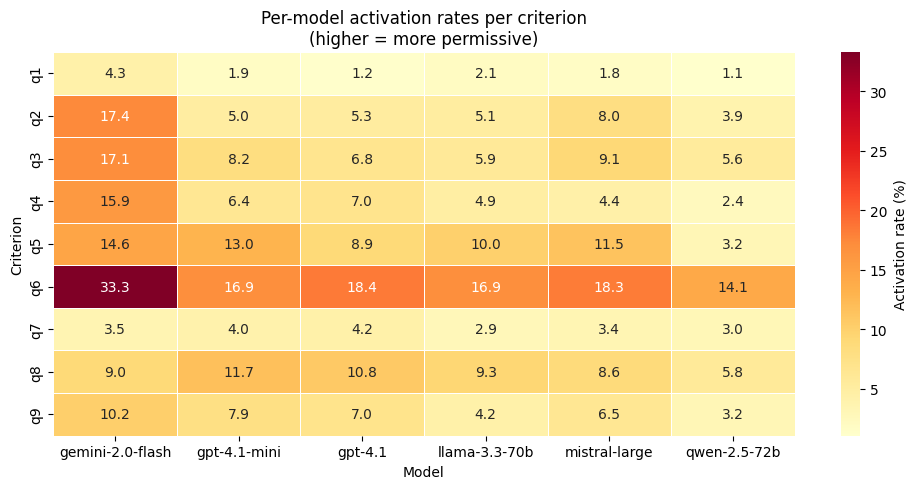

In [16]:
# Per-model activation rates
activation = np.zeros((N_CRITERIA, 6))
for m in range(6):
    for q in range(N_CRITERIA):
        votes = tensor_all[:, q, m]
        valid = votes != -1
        activation[q, m] = votes[valid].sum() / valid.sum() * 100

df_act = pd.DataFrame(activation, index=SHORT, columns=MODELS)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    df_act,
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"label": "Activation rate (%)"}
)
ax.set_title("Per-model activation rates per criterion\n(higher = more permissive)")
ax.set_xlabel("Model")
ax.set_ylabel("Criterion")
plt.tight_layout()
plt.savefig("../results/model_bias_heatmap.pdf", dpi=150, bbox_inches='tight')
plt.show()

## 4. Inter-model correlations per criterion

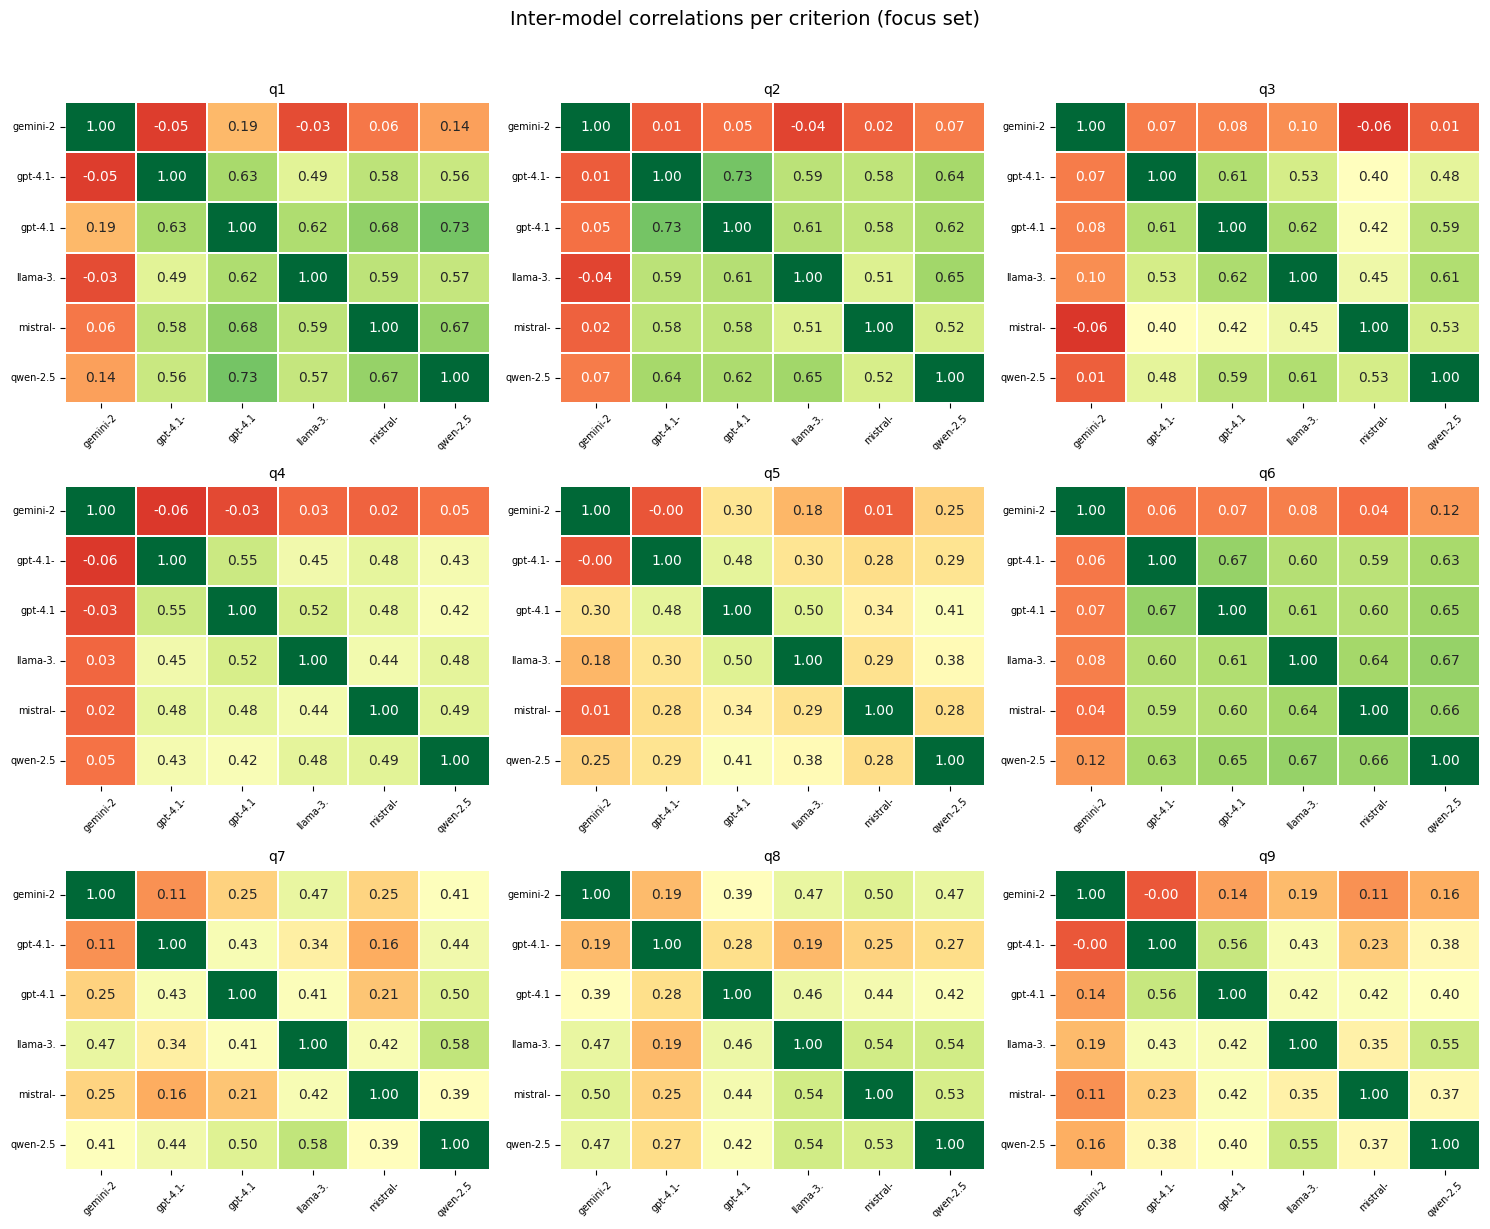


Inter-model correlation summary:
Criterion     Mean      Min      Max
q1           0.43    -0.05     0.73
q2           0.41    -0.04     0.73
q3           0.36    -0.06     0.62
q4           0.32    -0.06     0.55
q5           0.29     -0.0      0.5
q6           0.45     0.04     0.67
q7           0.36     0.11     0.58
q8           0.39     0.19     0.54
q9           0.31     -0.0     0.56


In [17]:
# ── For each criterion, compute pairwise model correlations ───────
# Correlation on binary votes (focus set only)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

correlations_summary = {}

for q_idx, (q_name, ax) in enumerate(zip(SHORT, axes)):
    # Get binary votes for this criterion across all models
    votes = tensor_all[:, q_idx, :]  # (N, 6)
    
    # Focus set: at least 1 model voted yes
    focus = (np.where(votes == -1, 0, votes).sum(axis=1) >= 1)
    votes_focus = votes[focus]
    votes_focus = np.where(votes_focus == -1, 0, votes_focus)
    
    # Pairwise correlation matrix
    df_votes = pd.DataFrame(votes_focus, columns=MODELS)
    corr = df_votes.corr()
    
    # Store off-diagonal correlations
    off_diag = corr.values[~np.eye(6, dtype=bool)]
    correlations_summary[q_name] = {
        'mean': round(np.mean(off_diag), 2),
        'min' : round(np.min(off_diag), 2),
        'max' : round(np.max(off_diag), 2),
    }
    
    sns.heatmap(
        corr,
        ax=ax,
        cmap="RdYlGn",
        vmin=-0.2, vmax=1,
        annot=True,
        fmt=".2f",
        linewidths=0.3,
        cbar=False,
        xticklabels=[m[:8] for m in MODELS],
        yticklabels=[m[:8] for m in MODELS],
    )
    ax.set_title(f"{q_name}", fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle("Inter-model correlations per criterion (focus set)", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../results/model_correlations_per_criterion.pdf", dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\nInter-model correlation summary:")
print(f"{'Criterion':<8} {'Mean':>8} {'Min':>8} {'Max':>8}")
for q, vals in correlations_summary.items():
    print(f"{q:<8} {vals['mean']:>8} {vals['min']:>8} {vals['max']:>8}")